In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
# plot Function
def plot_burstiness(result1):
    # Example burst data
    start_times = result1['ts']
    end_times = result1['te']
    counts = result1['count']

    # Bar width = end - start
    widths = [end - start for start, end in zip(start_times, end_times)]

    # All bars at y=0 since burst ID doesn't matter
    y_position = [0] * len(start_times)

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 3))

    for i in range(len(start_times)):
        ax.bar(
            x=start_times[i],     # left edge of the bar
            height=counts[i],     # height of the bar = count
            width=widths[i],      # width = end - start
            bottom=0,
            align='edge',
            edgecolor='black',
            alpha=0.7,
            label=f"Burst {i+1}",
            color='steelblue'
        )

    ax.set_xlabel("Time")
    ax.set_ylabel("Count")
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.set_title("I/O Burst Ranges Over Time")
    # ax.legend()
    # plt.grid(True, axis='x')
    plt.tight_layout()
    plt.show()


# Merge Results:
def merge_close_bursts(result_df):
    """
    Merge bursts in the DataFrame if the time between the end of one burst
    and the start of the next is less than the standard deviation of all such gaps.
    
    Parameters:
    - result_df: DataFrame with columns ['b_id', 'start_time', 'end_time', 'dur', 'size', 'count']
    
    Returns:
    - merged_result: DataFrame with merged bursts
    """

    # Step 1: Sort by start_time
    result_df = result_df.sort_values('start_time').reset_index(drop=True)

    # Step 2: Compute time gap between current end_time and next start_time
    result_df['gap'] = result_df['start_time'].shift(-1) - result_df['end_time']

    # Step 3: Calculate std of gaps, excluding the last row (gap=NaN)
    gap_std = result_df['gap'].dropna().std()

    # Step 4: Assign group IDs based on the std threshold
    group_id = 0
    group_ids = [group_id]
    for i in range(1, len(result_df)):
        if result_df.loc[i - 1, 'gap'] < gap_std:
            group_ids.append(group_id)
        else:
            group_id += 1
            group_ids.append(group_id)
    result_df['group_id'] = group_ids

    # Step 5: Merge the groups
    merged_result = result_df.groupby('group_id').agg(
        start_time=('start_time', 'min'),
        end_time=('end_time', 'max'),
        dur=('dur', 'sum'),
        size=('size', 'sum'),
        count=('count', 'sum')
    ).reset_index(drop=True)

    return merged_result


In [8]:
app_name = "deepspeed-dlio-scr-step100"
burst_data = "/p/lustre3/pandey2/logs/results_checkpoint/"+app_name+"/data_burst.csv"
df = pd.read_csv(burst_data)
df.head()

/var/tmp/pandey2/ipykernel_3172686/1336811290.py:3: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(burst_data)


,Unnamed: 0,id,name,cat,size,ts,te,dur,trange,mount_point,hostname,b_id
0,0,68902,read,POSIX,17258,1949132,1949473,341,0,/proc,corona207,68902
1,1,114594,read,POSIX,17258,1949153,1949465,312,0,/proc,corona207,68902
2,2,137435,read,POSIX,17258,1949157,1949468,311,0,/proc,corona207,68902
3,3,4927,read,POSIX,17258,1949159,1949498,339,0,/proc,corona207,68902
4,4,46058,read,POSIX,17258,1949183,1949497,314,0,/proc,corona207,68902


# Write Events in /p/lustre3

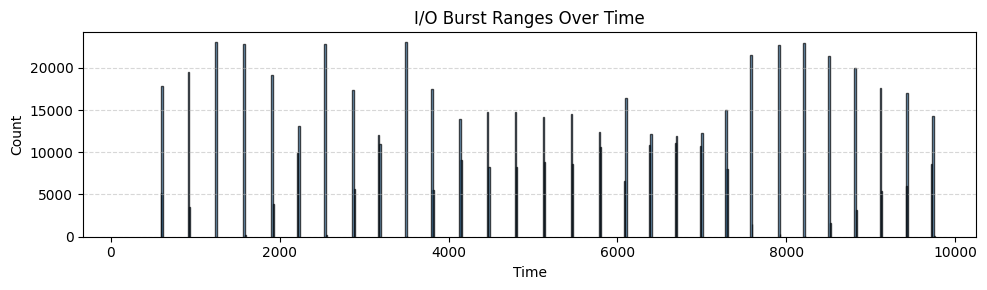

In [9]:
selected_events = df[
    (df['mount_point'] == "/p/lustre3") & (df['name'] == "write")
 ].reset_index(drop=True)

result = selected_events.groupby(['b_id']).agg(
    start_time=('ts', 'min'),
    end_time=('te', 'max'),
    dur = ('dur','sum'),
    size = ('size','sum'),
    count=('ts', 'count')  # or any column — all rows per group are counted
).reset_index()

result['ts'] = result['start_time']/1e6
result['te'] = result['end_time']/1e6
plot_burstiness(result)


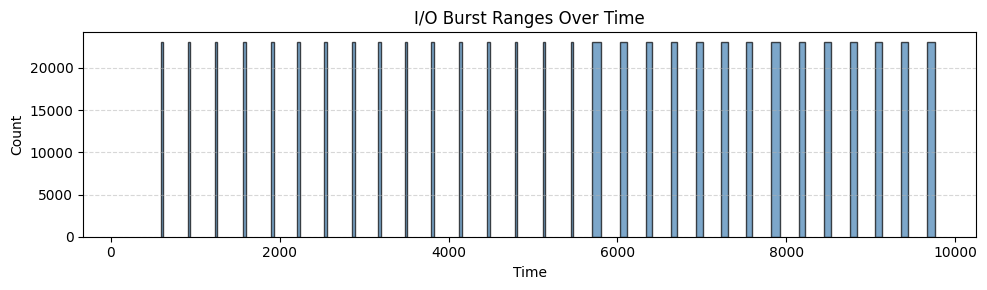

In [10]:
result = merge_close_bursts(result)
result['ts'] = result['start_time']/1e6
result['te'] = result['end_time']/1e6
plot_burstiness(result)

# Read Events in /usr/WS2

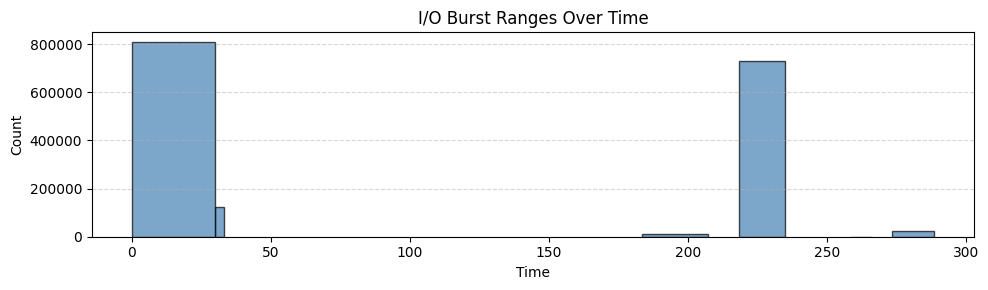

In [11]:
selected_events = df[
    (df['mount_point'] == "/usr/WS2") & (df['name'] == "read")
 ].reset_index(drop=True)

result = selected_events.groupby(['b_id']).agg(
    start_time=('ts', 'min'),
    end_time=('te', 'max'),
    dur = ('dur','sum'),
    size = ('size','sum'),
    count=('ts', 'count')  # or any column — all rows per group are counted
).reset_index()

result['ts'] = result['start_time']/1e6
result['te'] = result['end_time']/1e6
plot_burstiness(result)


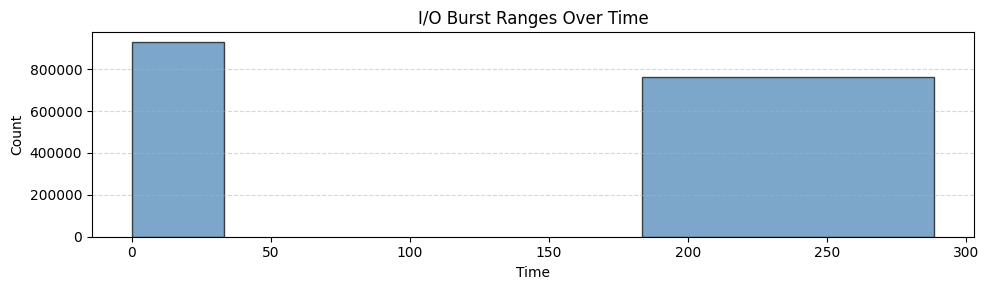

In [12]:
result = merge_close_bursts(result)
result['ts'] = result['start_time']/1e6
result['te'] = result['end_time']/1e6
plot_burstiness(result)

# All events in /l/ssd in single compute host


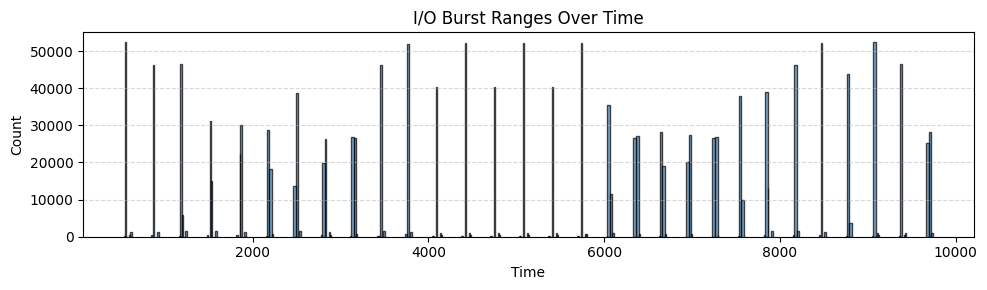

In [13]:
selected_events = df[
    (df['mount_point'] == "/l/ssd") & (df['hostname'] == "corona202")
 ].reset_index(drop=True)

result = selected_events.groupby(['b_id']).agg(
    start_time=('ts', 'min'),
    end_time=('te', 'max'),
    dur = ('dur','sum'),
    size = ('size','sum'),
    count=('ts', 'count')  # or any column — all rows per group are counted
).reset_index()

result['ts'] = result['start_time']/1e6
result['te'] = result['end_time']/1e6
plot_burstiness(result)

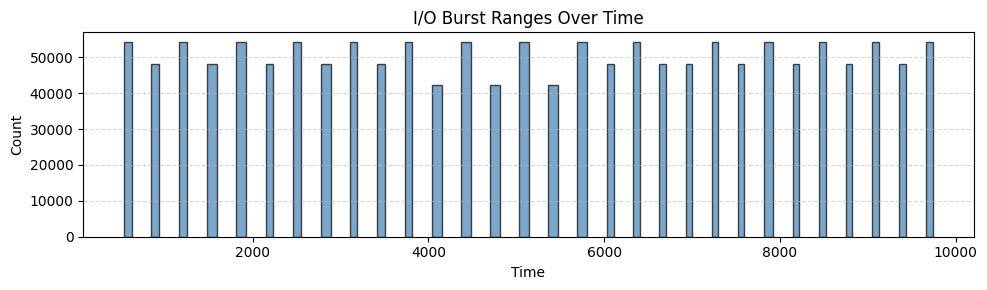

In [14]:
result = merge_close_bursts(result)
result['ts'] = result['start_time']/1e6
result['te'] = result['end_time']/1e6
plot_burstiness(result)